# Lab 3
### Averaging Filters

http://scikit-image.org/docs/0.13.x/api/skimage.util.html#skimage.util.random_noise

http://scikit-image.org/docs/dev/api/skimage.filters.html#skimage.filters.median

http://scikit-image.org/docs/dev/api/skimage.filters.html#skimage.filters.gaussian

In [1]:
import commonfunctions as cf
import math
from skimage.util import random_noise 
import imageio.v2 as imageio
from skimage.filters import median
from skimage.filters import gaussian
from skimage.color import rgb2gray
import numpy as np
%matplotlib inline
%load_ext autoreload
%autoreload 

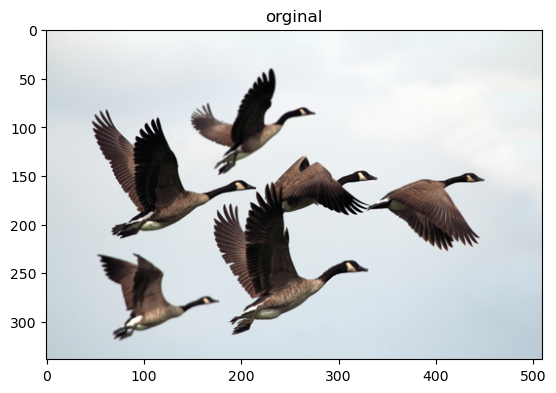

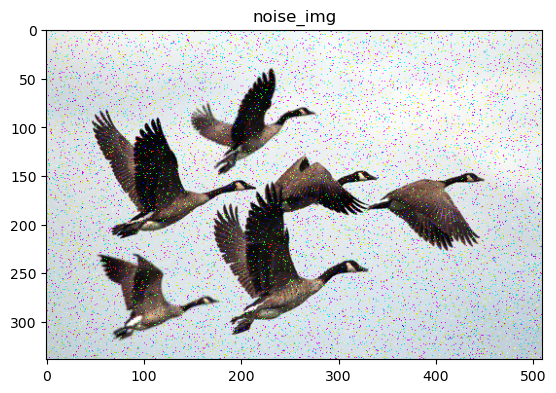

In [3]:
img= imageio.imread('birds.png')
cf.show_images([img],['orginal'])
noise_img=random_noise(img,mode='s&p',amount=0.05)
cf.show_images([noise_img],['noise_img'])

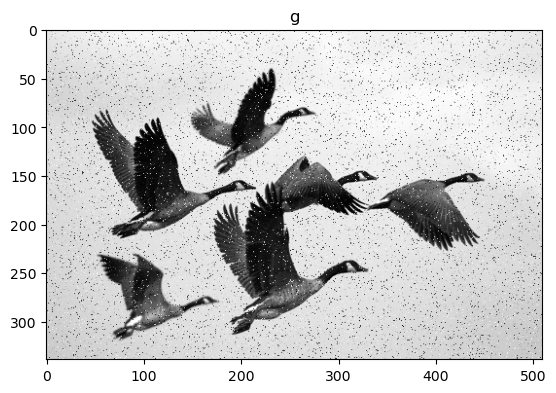

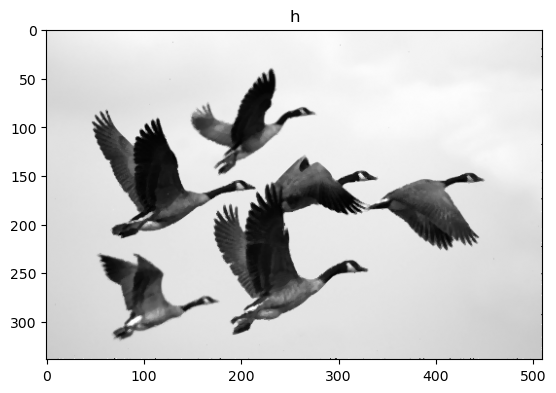

In [6]:

filter = np.ones((3, 3), dtype=np.uint8)
f_height, f_width = filter.shape
noise_imge=noise_img[:,:,:3]
gray_noise_img=rgb2gray(noise_imge)
gray_noise_img = (gray_noise_img * 255).astype(np.uint8)
cf.show_images([gray_noise_img],'gray_noise_img')
i_height, i_width = gray_noise_img.shape
output = np.copy(gray_noise_img)
edgex = math.floor(f_width / 2)
edgey = math.floor(f_height / 2)

for y in range(edgey, i_height - edgey):
    for x in range(edgex, i_width - edgex):
        temp = np.zeros((f_height, f_width), dtype=np.uint8)
        for fy in range(f_height):
            for fx in range(f_width):
                temp[fy][fx] = gray_noise_img[y + fy - edgey][x + fx - edgex]

        sorted_vals = np.sort(temp, axis=None)
        median_val = sorted_vals[math.floor(len(sorted_vals) / 2)]
        output[y][x] = median_val


cf.show_images([output],'hand_made_median')

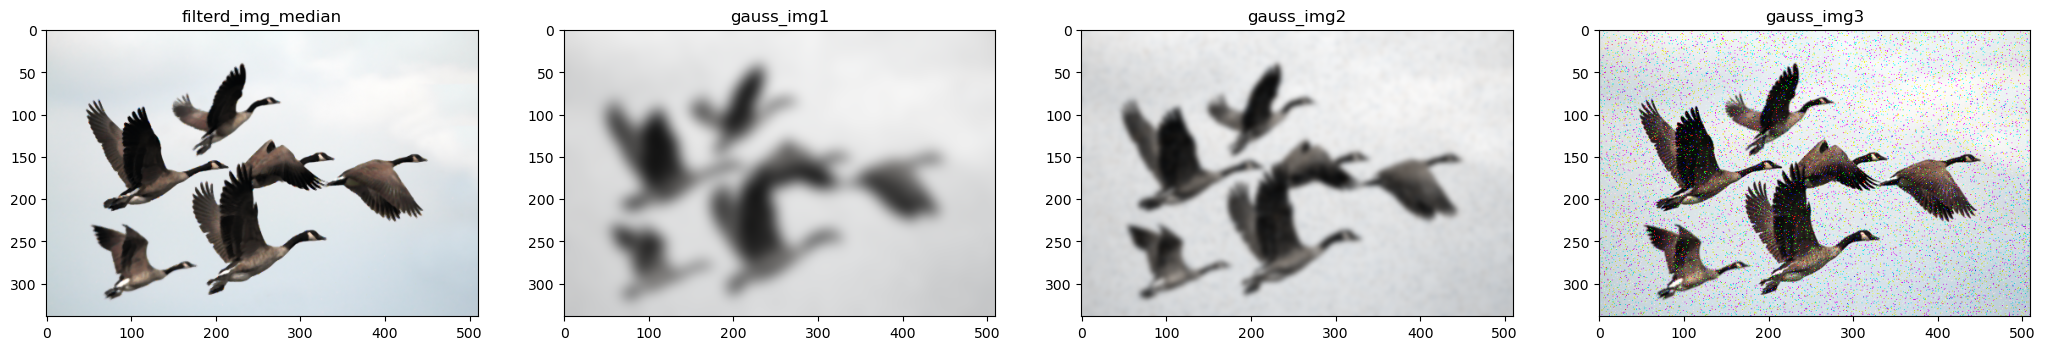

In [12]:
filterd_img_median=median(noise_img,footprint= None,out= None,mode='nearest',cval=0.0,behavior='ndimage')
gauss_img1=gaussian(noise_img,sigma=8)
gauss_img2=gaussian(noise_img,sigma=3)
gauss_img3=gaussian(noise_img,sigma=0.2)
cf.show_images([filterd_img_median,gauss_img1,gauss_img2,gauss_img3],['filterd_img_median','gauss_img1','gauss_img2','gauss_img3'])


In [ ]:
'''
(1) Your own median filter algorithm
'''

'\n(1) Your own median filter algorithm\n'

In [ ]:
'''
(2) skimage median filter
'''

'\n(2) skimage median filter\n'

In [ ]:
'''
(3) Gaussion Filters
'''

'\n(3) Gaussion Filters\n'